In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ------------------------------------------------------------------
# CONFIGURACIÓN: editá estas variables según lo que necesites
# ------------------------------------------------------------------
ARCHIVO = "UTILITY.xls"          # nombre (o ruta) del archivo Excel
COLUMNA = "Utility Charge"              # nombre de la columna a analizar
# ------------------------------------------------------------------


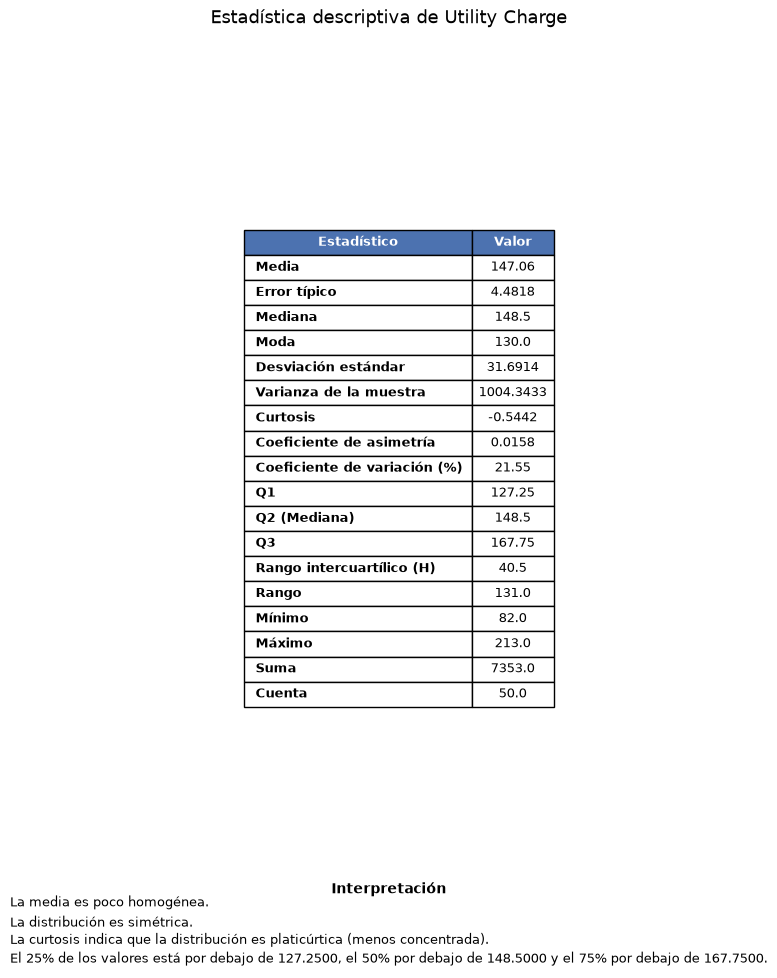

In [11]:
def cargar_datos(archivo: str, columna: str) -> pd.Series:
    ruta = archivo if os.path.isabs(archivo) else os.path.join(os.getcwd(), archivo)

    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontró el archivo: {ruta}")

    df = pd.read_excel(ruta)

    if columna not in df.columns:
        raise ValueError(
            f"La columna '{columna}' no existe en el archivo. "
            f"Columnas disponibles: {list(df.columns)}"
        )

    datos = pd.to_numeric(df[columna], errors="coerce").dropna()

    if datos.empty:
        raise ValueError(f"La columna '{columna}' no tiene datos numéricos.")

    return datos


def calcular_estadisticas(datos: pd.Series) -> pd.DataFrame:
    modas = datos.mode()
    moda = modas.iloc[0] if len(modas) < len(datos) else "No hay moda"
    media = datos.mean()
    desviacion_estandar = datos.std()
    coeficiente_variacion = (
        (desviacion_estandar / abs(media)) * 100 if abs(media) > 0 else 0.0
    )
    q1 = datos.quantile(0.25)
    q2 = datos.quantile(0.50)
    q3 = datos.quantile(0.75)
    rango_intercuartil = q3 - q1

    estadisticas = {
        "Media": media,
        "Error típico": datos.sem(),
        "Mediana": datos.median(),
        "Moda": moda,
        "Desviación estándar": desviacion_estandar,
        "Varianza de la muestra": datos.var(),
        "Curtosis": datos.kurtosis(),
        "Coeficiente de asimetría": datos.skew(),
        "Coeficiente de variación (%)": coeficiente_variacion,
        "Q1": q1,
        "Q2 (Mediana)": q2,
        "Q3": q3,
        "Rango intercuartílico (H)": rango_intercuartil,
        "Rango": datos.max() - datos.min(),
        "Mínimo": datos.min(),
        "Máximo": datos.max(),
        "Suma": datos.sum(),
        "Cuenta": datos.count(),
    }

    valores = [
        round(v, 4) if isinstance(v, (int, float)) else v
        for v in estadisticas.values()
    ]

    tabla = pd.DataFrame({
        "Estadístico": list(estadisticas.keys()),
        "Valor": valores,
    })

    return tabla


def interpretar_resultados(datos: pd.Series) -> str:
    media = datos.mean()
    desviacion_estandar = datos.std()
    coeficiente_variacion = (
        (desviacion_estandar / abs(media)) * 100 if abs(media) > 0 else 0.0
    )
    q1 = datos.quantile(0.25)
    q2 = datos.quantile(0.50)
    q3 = datos.quantile(0.75)
    curtosis = datos.kurtosis()

    if coeficiente_variacion <= 15:
        homogeneidad = "homogénea"
    elif coeficiente_variacion <= 30:
        homogeneidad = "poco homogénea"
    else:
        homogeneidad = "no homogénea"

    if curtosis > 0:
        curtosis_texto = "leptocúrtica (más concentrada)"
    elif curtosis < 0:
        curtosis_texto = "platicúrtica (menos concentrada)"
    else:
        curtosis_texto = "mesocúrtica (similar a la normal)"

    if abs(media - q2) <= 0.05 * max(abs(media), 1):
        asimetria = "es simétrica"
    elif media < q2:
        asimetria = "es asimétrica a la izquierda, subvaluando la media (media < mediana)"
    else:
        asimetria = "es asimétrica a la derecha, subestimando la media (mediana < media)"

    return (
        f"La media es {homogeneidad}.\n"
        f"La distribución {asimetria}.\n"
        f"La curtosis indica que la distribución es {curtosis_texto}.\n"
        f"El 25% de los valores está por debajo de {q1:.4f}, el 50% por debajo de {q2:.4f} "
        f"y el 75% por debajo de {q3:.4f}."
    )


def graficar_tabla(tabla: pd.DataFrame, columna: str, interpretacion: str):
    fig, ax = plt.subplots(figsize=(8, 0.5 * len(tabla) + 1.2))
    ax.axis("off")

    tabla_mpl = ax.table(
        cellText=tabla.values,
        colLabels=tabla.columns,
        cellLoc="center",
        loc="center",
    )
    tabla_mpl.auto_set_font_size(False)
    tabla_mpl.set_fontsize(9)
    tabla_mpl.scale(1, 1.45)
    tabla_mpl.auto_set_column_width(col=list(range(len(tabla.columns))))

    for (fila, col), celda in tabla_mpl.get_celld().items():
        celda.set_edgecolor("black")
        if fila == 0:
            celda.set_facecolor("#4C72B0")
            celda.set_text_props(color="white", weight="bold")
        elif col == 0:
            celda.set_text_props(weight="bold", ha="left")
            celda.PAD = 0.05

    fig.suptitle(f"Estadística descriptiva de {columna}", fontsize=13, y=0.97)
    fig.text(
        0.5,
        0.10,
        "Interpretación",
        ha="center",
        va="bottom",
        fontsize=10,
        weight="bold",
    )
    fig.text(
        0.5,
        0.03,
        interpretacion,
        ha="center",
        va="bottom",
        fontsize=9,
        linespacing=1.5,
        multialignment="left",
    )
    plt.subplots_adjust(top=0.92, bottom=0.12)
    plt.show()


def main():
    datos = cargar_datos(ARCHIVO, COLUMNA)
    tabla = calcular_estadisticas(datos)
    interpretacion = interpretar_resultados(datos)
    graficar_tabla(tabla, COLUMNA, interpretacion)


if __name__ == "__main__":
    main()
